In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"



Import data and unzip


In [1]:
import os

# Set the project path to the directory containing this notebook and results.csv
project_path = os.path.dirname(os.path.abspath('__file__'))
print(f"Project directory: {project_path}")

# List files to verify content
print("Files in directory:")
print(os.listdir(project_path))


Project directory: /Users/macbookpro/University_Assignments/machine_learning/Premier-League-Predictive-Analysis
Files in directory:
['train_env', '.DS_Store', 'Machine Learning Analysis of English Premier League Matches.pdf', 'FinalProject_Kmeans_andPCS.py', 'README.md', '.gitignore', '.git', 'XGBoost_NN.ipynb', 'Data', 'results.csv', 'FinalProject_LogReg.py']


Data pipelining

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the Data
df = pd.read_csv(os.path.join(project_path, 'results.csv'), encoding='latin1')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values(by='DateTime').reset_index(drop=True)

# Drop missing values for ALL the stats we want to track now
stats_to_keep = ['FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF']
df_clean = df.dropna(subset=stats_to_keep).copy()

df_clean['Target'] = df_clean['FTR'].map({'H': 0, 'A': 1, 'D': 2})

# 2. The EXPANDED "Pre-Game Form" Function
def get_team_form_expanded(data):
    team_stats = []
    # Now tracking: [Scored, Conceded, Shots, ShotsOnTarget, Corners, Fouls]
    team_history = {}

    for index, row in data.iterrows():
        home = row['HomeTeam']
        away = row['AwayTeam']

        if home not in team_history: team_history[home] = []
        if away not in team_history: team_history[away] = []

        # Calculate Rolling Averages for Home Team (last 5 games)
        if len(team_history[home]) >= 5:
            h_recent = team_history[home][-5:]
            h_Scored = sum(x[0] for x in h_recent) / 5.0
            h_Conceded = sum(x[1] for x in h_recent) / 5.0
            h_Shots = sum(x[2] for x in h_recent) / 5.0
            h_SoT = sum(x[3] for x in h_recent) / 5.0
            h_Corners = sum(x[4] for x in h_recent) / 5.0
            h_Fouls = sum(x[5] for x in h_recent) / 5.0
        else:
            h_Scored, h_Conceded, h_Shots, h_SoT, h_Corners, h_Fouls = -1, -1, -1, -1, -1, -1

        # Calculate Rolling Averages for Away Team (last 5 games)
        if len(team_history[away]) >= 5:
            a_recent = team_history[away][-5:]
            a_Scored = sum(x[0] for x in a_recent) / 5.0
            a_Conceded = sum(x[1] for x in a_recent) / 5.0
            a_Shots = sum(x[2] for x in a_recent) / 5.0
            a_SoT = sum(x[3] for x in a_recent) / 5.0
            a_Corners = sum(x[4] for x in a_recent) / 5.0
            a_Fouls = sum(x[5] for x in a_recent) / 5.0
        else:
            a_Scored, a_Conceded, a_Shots, a_SoT, a_Corners, a_Fouls = -1, -1, -1, -1, -1, -1

        team_stats.append({
            'Home_Avg_Scored': h_Scored, 'Home_Avg_Conceded': h_Conceded,
            'Home_Avg_Shots': h_Shots, 'Home_Avg_SoT': h_SoT,
            'Home_Avg_Corners': h_Corners, 'Home_Avg_Fouls': h_Fouls,

            'Away_Avg_Scored': a_Scored, 'Away_Avg_Conceded': a_Conceded,
            'Away_Avg_Shots': a_Shots, 'Away_Avg_SoT': a_SoT,
            'Away_Avg_Corners': a_Corners, 'Away_Avg_Fouls': a_Fouls
        })

        # Update histories: [Scored, Conceded, Shots, SoT, Corners, Fouls]
        team_history[home].append([row['FTHG'], row['FTAG'], row['HS'], row['HST'], row['HC'], row['HF']])
        team_history[away].append([row['FTAG'], row['FTHG'], row['AS'], row['AST'], row['AC'], row['AF']])

    return pd.DataFrame(team_stats, index=data.index)

# 3. Apply and Clean
print("Engineering expanded rolling features...")
new_features = get_team_form_expanded(df_clean)
df_engineered = pd.concat([df_clean, new_features], axis=1)
df_model = df_engineered[df_engineered['Home_Avg_Scored'] != -1].copy()

# 4. Our 12 New Pre-Game Features
model_features = [
    'Home_Avg_Scored', 'Home_Avg_Conceded', 'Home_Avg_Shots', 'Home_Avg_SoT', 'Home_Avg_Corners', 'Home_Avg_Fouls',
    'Away_Avg_Scored', 'Away_Avg_Conceded', 'Away_Avg_Shots', 'Away_Avg_SoT', 'Away_Avg_Corners', 'Away_Avg_Fouls'
]

X = df_model[model_features]
y = df_model['Target']

# 5. Split and Scale
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Total Matches Ready: {len(df_model)}")
print(f"Number of Features: {len(model_features)}")
print("Phase 1 (Expanded) Complete!")

Engineering expanded rolling features...
Total Matches Ready: 8182
Number of Features: 12
Phase 1 (Expanded) Complete!


Save data so for future use

In [3]:
import numpy as np
import joblib
import os

# 2. Create a safe project directory in your Drive
save_dir = os.path.join(project_path, 'Data')
os.makedirs(save_dir, exist_ok=True)

# 3. Save the Scaled Features (as highly efficient numpy files)
np.save(f'{save_dir}/X_train_scaled.npy', X_train_scaled)
np.save(f'{save_dir}/X_val_scaled.npy', X_val_scaled)
np.save(f'{save_dir}/X_test_scaled.npy', X_test_scaled)

# 4. Save the Target Labels
np.save(f'{save_dir}/y_train.npy', y_train.to_numpy())
np.save(f'{save_dir}/y_val.npy', y_val.to_numpy())
np.save(f'{save_dir}/y_test.npy', y_test.to_numpy())

# 5. Save the StandardScaler Object (CRITICAL)
joblib.dump(scaler, f'{save_dir}/scaler.joblib')

print(f"Success! All matrices and the scaler are safely stored in: {save_dir}")

Success! All matrices and the scaler are safely stored in: /Users/macbookpro/University_Assignments/machine_learning/Premier-League-Predictive-Analysis/Data


XGBoost testing

In [4]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# 1. Load the perfectly preserved data from your Google Drive
load_dir = os.path.join(project_path, 'Data')

print("Loading data arrays...")
X_train = np.load(f'{load_dir}/X_train_scaled.npy')
X_val = np.load(f'{load_dir}/X_val_scaled.npy')
y_train = np.load(f'{load_dir}/y_train.npy')
y_val = np.load(f'{load_dir}/y_val.npy')

# 2. Instantiate the Base XGBoost Classifier
# objective='multi:softmax' is required for our 3 classes (0: Home, 1: Away, 2: Draw)
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

# 3. Define the Hyperparameter Grid
# This tests different combinations to find the mathematical "sweet spot"
param_grid = {
    'n_estimators': [50, 100, 200],      # Number of trees
    'learning_rate': [0.01, 0.1, 0.2],   # How aggressively it corrects errors
    'max_depth': [3, 5, 7]               # How complex each tree is allowed to get
}

# 4. Execute Grid Search with Cross-Validation
print("Initiating Grid Search for Hyperparameter Tuning... (This may take a minute)")
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,                 # 3-fold cross validation
    scoring='accuracy',
    verbose=1,
    n_jobs=-1             # Uses all available CPU cores
)

grid_search.fit(X_train, y_train)

# 5. Extract the Champion Model
champion_model = grid_search.best_estimator_
print(f"\nOptimal Parameters Found: {grid_search.best_params_}")

# 6. Evaluate on the Validation Set (Unseen data!)
print("\nEvaluating Champion Model on Validation Set...")
y_val_pred = champion_model.predict(X_val)

# Target Mapping Reminder for the report: 0: Home Win, 1: Away Win, 2: Draw
target_names = ['Home Win (0)', 'Away Win (1)', 'Draw (2)']

print("\n--- XGBoost Classification Report ---")
print(classification_report(y_val, y_val_pred, target_names=target_names))

# 7. Save the Champion Model safely to Drive
champion_model.save_model(f'{load_dir}/xgboost_champion.json')
print(f"\nChampion Model successfully saved to: {load_dir}/xgboost_champion.json")

Loading data arrays...
Initiating Grid Search for Hyperparameter Tuning... (This may take a minute)
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Optimal Parameters Found: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}

Evaluating Champion Model on Validation Set...

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

Home Win (0)       0.52      0.89      0.66       564
Away Win (1)       0.47      0.34      0.39       358
    Draw (2)       0.20      0.00      0.01       305

    accuracy                           0.51      1227
   macro avg       0.40      0.41      0.35      1227
weighted avg       0.43      0.51      0.42      1227


Champion Model successfully saved to: /Users/macbookpro/University_Assignments/machine_learning/Premier-League-Predictive-Analysis/Data/xgboost_champion.json


learning curve graph

Extracting optimal parameters to plot the Learning Curve...


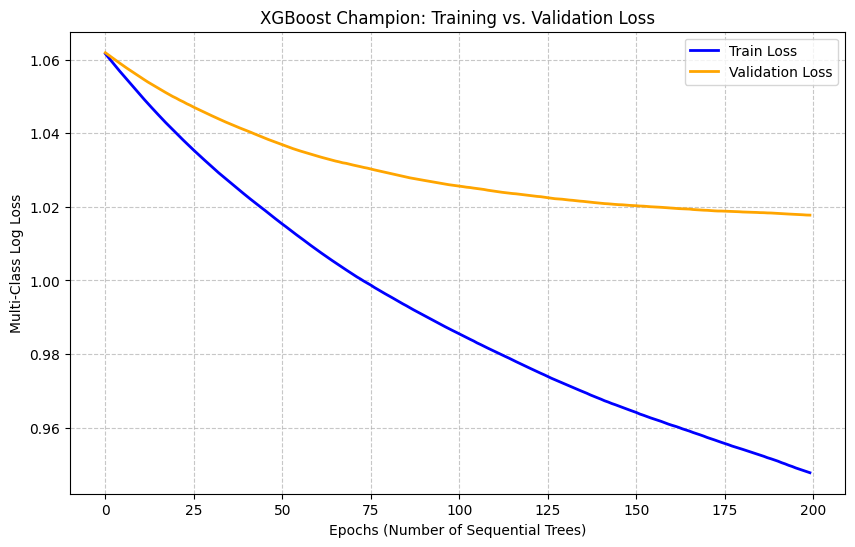

In [5]:
import matplotlib.pyplot as plt

print("Extracting optimal parameters to plot the Learning Curve...")
best_params = grid_search.best_params_

# 1. Instantiate a new model strictly using the winning parameters
final_champion = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    **best_params  # This injects the winning settings
)

# 2. Define the evaluation sets so the model can track its own progress
eval_set = [(X_train, y_train), (X_val, y_val)]

# 3. Fit the model and record the loss at every single tree (epoch)
final_champion.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False # Set to True if you want it to print every single step
)

# 4. Extract the tracking data
results = final_champion.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

# 5. Plot the beautiful Learning Curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_axis, results['validation_0']['mlogloss'], label='Train Loss', color='blue', linewidth=2)
ax.plot(x_axis, results['validation_1']['mlogloss'], label='Validation Loss', color='orange', linewidth=2)
ax.legend()
plt.ylabel('Multi-Class Log Loss')
plt.xlabel('Epochs (Number of Sequential Trees)')
plt.title('XGBoost Champion: Training vs. Validation Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Testing with class weight

In [6]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight

# 1. Load your existing data
load_dir = os.path.join(project_path, 'Data')
X_train = np.load(f'{load_dir}/X_train_scaled.npy')
X_val = np.load(f'{load_dir}/X_val_scaled.npy')
y_train = np.load(f'{load_dir}/y_train.npy')
y_val = np.load(f'{load_dir}/y_val.npy')

# 2. Instantiate the Base XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

# 3. Use the EXACT SAME Grid as baseline for a true comparison
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# --- THE NEW ADDITION: CALCULATE WEIGHTS ---
print("Calculating balanced class weights...")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 4. Execute Grid Search WITH the weights applied
print("Initiating Grid Search with Sample Weights...")
grid_search.fit(
    X_train,
    y_train,
    sample_weight=sample_weights # Forcing the model to penalize missed Draws
)

# 5. Evaluate the Weighted Model
weighted_champion = grid_search.best_estimator_
y_val_pred = weighted_champion.predict(X_val)

target_names = ['Home Win (0)', 'Away Win (1)', 'Draw (2)']
print("\n--- EXPERIMENT 1: Weighted XGBoost Classification Report ---")
print(classification_report(y_val, y_val_pred, target_names=target_names))

Calculating balanced class weights...
Initiating Grid Search with Sample Weights...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

--- EXPERIMENT 1: Weighted XGBoost Classification Report ---
              precision    recall  f1-score   support

Home Win (0)       0.60      0.52      0.56       564
Away Win (1)       0.43      0.52      0.47       358
    Draw (2)       0.26      0.26      0.26       305

    accuracy                           0.45      1227
   macro avg       0.43      0.43      0.43      1227
weighted avg       0.47      0.45      0.46      1227



Learning curve

Extracting optimal parameters for the Weighted Learning Curve...


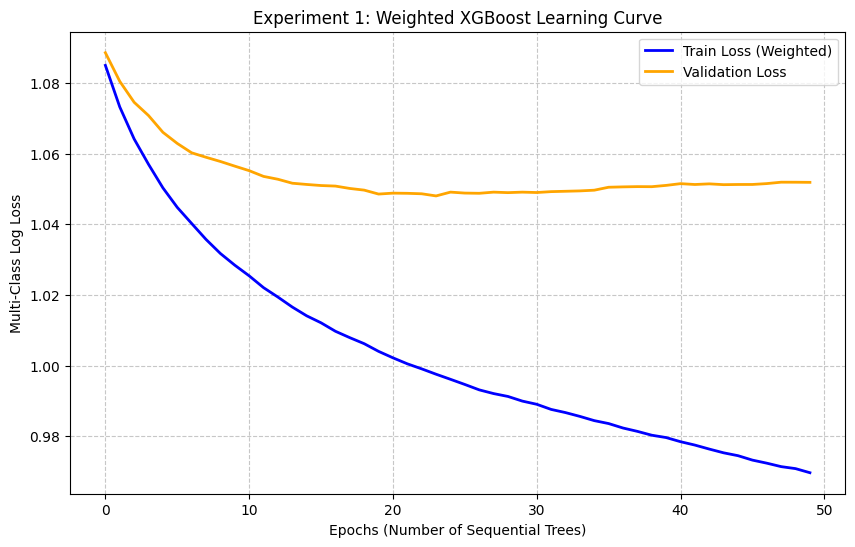

In [7]:
import matplotlib.pyplot as plt

print("Extracting optimal parameters for the Weighted Learning Curve...")
best_params_weighted = grid_search.best_params_

# 1. Instantiate a new model using the winning parameters
weighted_curve_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    **best_params_weighted  # Inject the winning settings
)

# 2. Define the evaluation sets so it can track its progress
eval_set = [(X_train, y_train), (X_val, y_val)]

# 3. Fit the model WITH the sample weights to precisely recreate Experiment 1
weighted_curve_model.fit(
    X_train, y_train,
    sample_weight=sample_weights, # Crucial: keep the weights!
    eval_set=eval_set,
    verbose=False
)

# 4. Extract the tracking data
results = weighted_curve_model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

# 5. Plot the beautiful Learning Curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_axis, results['validation_0']['mlogloss'], label='Train Loss (Weighted)', color='blue', linewidth=2)
ax.plot(x_axis, results['validation_1']['mlogloss'], label='Validation Loss', color='orange', linewidth=2)
ax.legend()
plt.ylabel('Multi-Class Log Loss')
plt.xlabel('Epochs (Number of Sequential Trees)')
plt.title('Experiment 1: Weighted XGBoost Learning Curve')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Advance feature engineering

In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight
import joblib

# ==========================================
# PART A: ADVANCED FEATURE ENGINEERING
# ==========================================
df = pd.read_csv(os.path.join(project_path, 'results.csv'), encoding='latin1')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values(by='DateTime').reset_index(drop=True)

stats_to_keep = ['FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF']
df_clean = df.dropna(subset=stats_to_keep).copy()
df_clean['Target'] = df_clean['FTR'].map({'H': 0, 'A': 1, 'D': 2})

def get_team_form_advanced(data):
    team_stats = []
    # History Tracker: [Scored, Conceded, Shots, SoT, Corners, Fouls, Points]
    team_history = {}

    for index, row in data.iterrows():
        home = row['HomeTeam']
        away = row['AwayTeam']

        if home not in team_history: team_history[home] = []
        if away not in team_history: team_history[away] = []

        # Calculate Rolling Averages for Home Team (last 5 games)
        if len(team_history[home]) >= 5:
            h_recent = team_history[home][-5:]
            h_Scored = sum(x[0] for x in h_recent) / 5.0
            h_Conceded = sum(x[1] for x in h_recent) / 5.0
            h_Shots = sum(x[2] for x in h_recent) / 5.0
            h_SoT = sum(x[3] for x in h_recent) / 5.0
            h_Corners = sum(x[4] for x in h_recent) / 5.0
            h_Fouls = sum(x[5] for x in h_recent) / 5.0
            h_Points = sum(x[6] for x in h_recent) / 5.0
            h_GoalDiff = h_Scored - h_Conceded # New Momentum Feature
        else:
            h_Scored, h_Conceded, h_Shots, h_SoT, h_Corners, h_Fouls, h_Points, h_GoalDiff = [-1]*8

        # Calculate Rolling Averages for Away Team (last 5 games)
        if len(team_history[away]) >= 5:
            a_recent = team_history[away][-5:]
            a_Scored = sum(x[0] for x in a_recent) / 5.0
            a_Conceded = sum(x[1] for x in a_recent) / 5.0
            a_Shots = sum(x[2] for x in a_recent) / 5.0
            a_SoT = sum(x[3] for x in a_recent) / 5.0
            a_Corners = sum(x[4] for x in a_recent) / 5.0
            a_Fouls = sum(x[5] for x in a_recent) / 5.0
            a_Points = sum(x[6] for x in a_recent) / 5.0
            a_GoalDiff = a_Scored - a_Conceded # New Momentum Feature
        else:
            a_Scored, a_Conceded, a_Shots, a_SoT, a_Corners, a_Fouls, a_Points, a_GoalDiff = [-1]*8

        team_stats.append({
            'Home_Avg_Scored': h_Scored, 'Home_Avg_Conceded': h_Conceded, 'Home_Avg_Shots': h_Shots,
            'Home_Avg_SoT': h_SoT, 'Home_Avg_Corners': h_Corners, 'Home_Avg_Fouls': h_Fouls,
            'Home_Avg_Points': h_Points, 'Home_Goal_Diff': h_GoalDiff,

            'Away_Avg_Scored': a_Scored, 'Away_Avg_Conceded': a_Conceded, 'Away_Avg_Shots': a_Shots,
            'Away_Avg_SoT': a_SoT, 'Away_Avg_Corners': a_Corners, 'Away_Avg_Fouls': a_Fouls,
            'Away_Avg_Points': a_Points, 'Away_Goal_Diff': a_GoalDiff
        })

        # Calculate Match Points for the tracker
        if row['FTHG'] > row['FTAG']:
            h_match_pts, a_match_pts = 3, 0
        elif row['FTHG'] == row['FTAG']:
            h_match_pts, a_match_pts = 1, 1
        else:
            h_match_pts, a_match_pts = 0, 3

        # Update histories: [Scored, Conceded, Shots, SoT, Corners, Fouls, Points]
        team_history[home].append([row['FTHG'], row['FTAG'], row['HS'], row['HST'], row['HC'], row['HF'], h_match_pts])
        team_history[away].append([row['FTAG'], row['FTHG'], row['AS'], row['AST'], row['AC'], row['AF'], a_match_pts])

    return pd.DataFrame(team_stats, index=data.index)

print("Engineering advanced rolling features (Points & Goal Difference)...")
new_features = get_team_form_advanced(df_clean)
df_engineered = pd.concat([df_clean, new_features], axis=1)

# Drop initial unpopulated rows
df_model = df_engineered[df_engineered['Home_Avg_Scored'] != -1].copy()

# Our upgraded 16 Pre-Game Features
model_features = [
    'Home_Avg_Scored', 'Home_Avg_Conceded', 'Home_Avg_Shots', 'Home_Avg_SoT', 'Home_Avg_Corners', 'Home_Avg_Fouls', 'Home_Avg_Points', 'Home_Goal_Diff',
    'Away_Avg_Scored', 'Away_Avg_Conceded', 'Away_Avg_Shots', 'Away_Avg_SoT', 'Away_Avg_Corners', 'Away_Avg_Fouls', 'Away_Avg_Points', 'Away_Goal_Diff'
]

X = df_model[model_features]
y = df_model['Target']

# Split and Scale
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# PART B: EXPERIMENT 2 TRAINING
# ==========================================
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42, eval_metric='mlogloss')

# Same grid as Experiment 1 to isolate the variable
param_grid = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7]}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

print("\nCalculating balanced class weights...")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("Initiating Grid Search with Advanced Features and Weights...")
grid_search.fit(X_train_scaled, y_train, sample_weight=sample_weights)

adv_champion = grid_search.best_estimator_
y_val_pred = adv_champion.predict(X_val_scaled)

print("\n--- EXPERIMENT 2: Advanced Features + Weights ---")
print(classification_report(y_val, y_val_pred, target_names=['Home Win (0)', 'Away Win (1)', 'Draw (2)']))

# Save the new upgraded arrays safely to Drive
load_dir = os.path.join(project_path, 'Data')
np.save(f'{load_dir}/X_train_adv.npy', X_train_scaled)
np.save(f'{load_dir}/X_val_adv.npy', X_val_scaled)
np.save(f'{load_dir}/X_test_adv.npy', X_test_scaled)
joblib.dump(scaler, f'{load_dir}/scaler_adv.joblib')

Engineering advanced rolling features (Points & Goal Difference)...

Calculating balanced class weights...
Initiating Grid Search with Advanced Features and Weights...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

--- EXPERIMENT 2: Advanced Features + Weights ---
              precision    recall  f1-score   support

Home Win (0)       0.59      0.49      0.53       564
Away Win (1)       0.41      0.52      0.46       358
    Draw (2)       0.24      0.23      0.23       305

    accuracy                           0.43      1227
   macro avg       0.41      0.41      0.41      1227
weighted avg       0.45      0.43      0.44      1227



['/Users/macbookpro/University_Assignments/machine_learning/Premier-League-Predictive-Analysis/Data/scaler_adv.joblib']

Learning curve

Extracting optimal parameters for Experiment 2 Learning Curve...


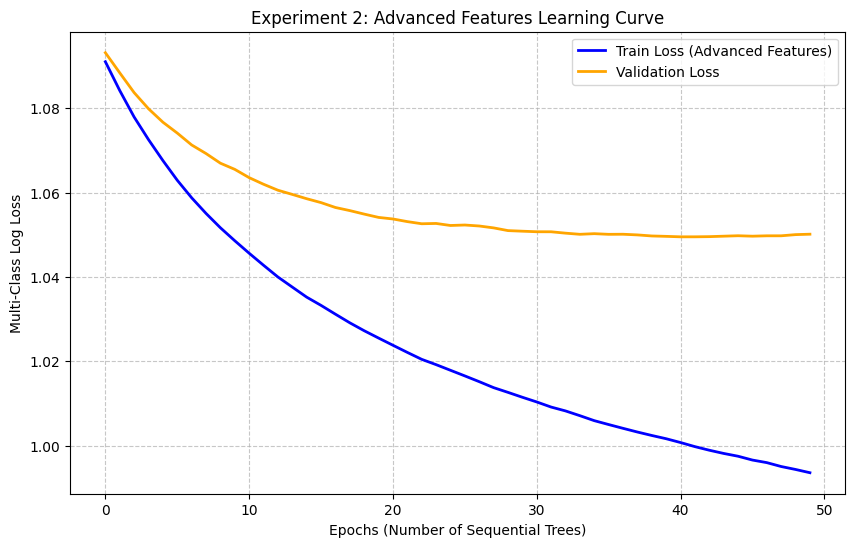

In [9]:
import matplotlib.pyplot as plt

print("Extracting optimal parameters for Experiment 2 Learning Curve...")
best_params_adv = grid_search.best_params_

# 1. Instantiate a new model using the winning parameters from Exp 2
adv_curve_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    **best_params_adv  # Inject the winning settings
)

# 2. Define the evaluation sets using your NEW 16-feature scaled data
eval_set_adv = [(X_train_scaled, y_train), (X_val_scaled, y_val)]

# 3. Fit the model WITH the sample weights
adv_curve_model.fit(
    X_train_scaled, y_train,
    sample_weight=sample_weights,
    eval_set=eval_set_adv,
    verbose=False
)

# 4. Extract the tracking data
results_adv = adv_curve_model.evals_result()
epochs_adv = len(results_adv['validation_0']['mlogloss'])
x_axis_adv = range(0, epochs_adv)

# 5. Plot the Learning Curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_axis_adv, results_adv['validation_0']['mlogloss'], label='Train Loss (Advanced Features)', color='blue', linewidth=2)
ax.plot(x_axis_adv, results_adv['validation_1']['mlogloss'], label='Validation Loss', color='orange', linewidth=2)
ax.legend()
plt.ylabel('Multi-Class Log Loss')
plt.xlabel('Epochs (Number of Sequential Trees)')
plt.title('Experiment 2: Advanced Features Learning Curve')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Heavy regularizaton

In [10]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight

# 1. Load the 16-Feature Advanced Dataset from Experiment 2
load_dir = os.path.join(project_path, 'Data')
X_train_scaled = np.load(f'{load_dir}/X_train_adv.npy')
X_val_scaled = np.load(f'{load_dir}/X_val_adv.npy')
y_train = np.load(f'{load_dir}/y_train.npy') # Targets are exactly the same
y_val = np.load(f'{load_dir}/y_val.npy')

# 2. Instantiate Base Model
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)

# 3. The EXPANDED Parameter Grid (Focusing on Anti-Overfitting)
param_grid = {
    'n_estimators': [100, 300, 500],      # Testing longer training runs
    'learning_rate': [0.01, 0.05, 0.1],   # Testing more granular step sizes
    'max_depth': [3, 5, 7, 9],            # 3 forces simplicity, 9 allows deep complexity
    'subsample': [0.8],                   # Anti-overfitting: Use only 80% of matches per tree
    'colsample_bytree': [0.8]             # Anti-overfitting: Use only 80% of features per tree
}

# 4. Calculate Weights to respect Draws
print("Calculating balanced class weights...")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 5. Execute Expanded Grid Search
# Note: 3*3*4*1*1 = 36 combinations * 3 folds = 108 total model fits
grid_search_exp3 = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("Initiating EXPANDED Grid Search... (This will take a few minutes!)")
grid_search_exp3.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# 6. Evaluate the Ultimate Champion
ultimate_champion = grid_search_exp3.best_estimator_
print(f"\nUltimate Optimal Parameters Found: {grid_search_exp3.best_params_}")

y_val_pred = ultimate_champion.predict(X_val_scaled)
print("\n--- EXPERIMENT 3: Expanded Grid + Advanced Features + Weights ---")
print(classification_report(y_val, y_val_pred, target_names=['Home Win (0)', 'Away Win (1)', 'Draw (2)']))

# Save the final optimized XGBoost model
ultimate_champion.save_model(f'{load_dir}/xgboost_ultimate_champion.json')

Calculating balanced class weights...
Initiating EXPANDED Grid Search... (This will take a few minutes!)
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Ultimate Optimal Parameters Found: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

--- EXPERIMENT 3: Expanded Grid + Advanced Features + Weights ---
              precision    recall  f1-score   support

Home Win (0)       0.59      0.45      0.51       564
Away Win (1)       0.42      0.50      0.46       358
    Draw (2)       0.23      0.28      0.25       305

    accuracy                           0.42      1227
   macro avg       0.41      0.41      0.41      1227
weighted avg       0.45      0.42      0.43      1227



Learning curve

Extracting optimal parameters for Experiment 3 Learning Curve...


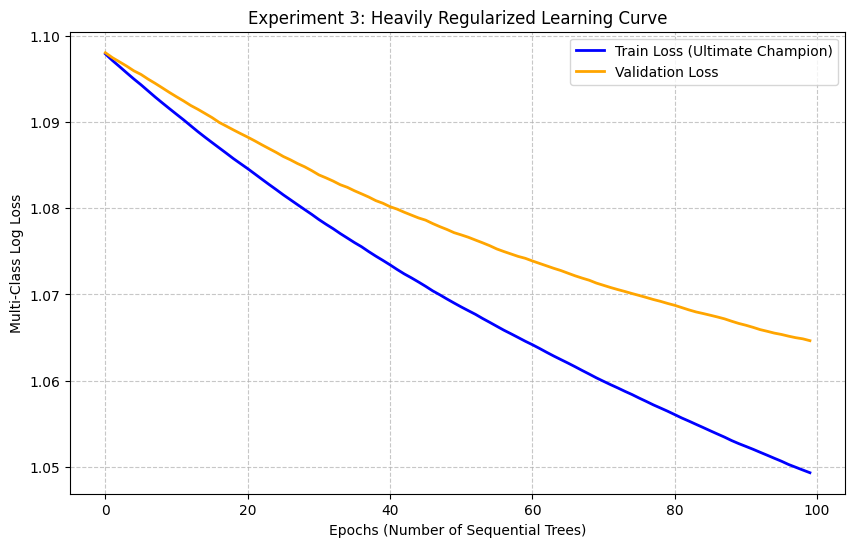

In [11]:
import matplotlib.pyplot as plt

print("Extracting optimal parameters for Experiment 3 Learning Curve...")
best_params_exp3 = grid_search_exp3.best_params_

# 1. Instantiate a new model using the winning parameters from Exp 3
exp3_curve_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    **best_params_exp3  # Inject the heavily regularized settings
)

# 2. Define the evaluation sets using your 16-feature scaled data
eval_set_exp3 = [(X_train_scaled, y_train), (X_val_scaled, y_val)]

# 3. Fit the model WITH the sample weights
exp3_curve_model.fit(
    X_train_scaled, y_train,
    sample_weight=sample_weights,
    eval_set=eval_set_exp3,
    verbose=False
)

# 4. Extract the tracking data
results_exp3 = exp3_curve_model.evals_result()
epochs_exp3 = len(results_exp3['validation_0']['mlogloss'])
x_axis_exp3 = range(0, epochs_exp3)

# 5. Plot the final Learning Curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_axis_exp3, results_exp3['validation_0']['mlogloss'], label='Train Loss (Ultimate Champion)', color='blue', linewidth=2)
ax.plot(x_axis_exp3, results_exp3['validation_1']['mlogloss'], label='Validation Loss', color='orange', linewidth=2)
ax.legend()
plt.ylabel('Multi-Class Log Loss')
plt.xlabel('Epochs (Number of Sequential Trees)')
plt.title('Experiment 3: Heavily Regularized Learning Curve')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Neural Network Experiment

Load data and handle data

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

# 1. Device Configuration (Use GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Load the 16-feature data
load_dir = os.path.join(project_path, 'Data')
X_train = np.load(f'{load_dir}/X_train_adv.npy')
X_val = np.load(f'{load_dir}/X_val_adv.npy')
y_train = np.load(f'{load_dir}/y_train.npy')
y_val = np.load(f'{load_dir}/y_val.npy')

# 3. Custom Dataset Class
class MatchDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MatchDataset(X_train, y_train)
val_dataset = MatchDataset(X_val, y_val)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/macbookpro/University_Assignments/machine_learning/Premier-League-Predictive-Analysis/train_env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/macbookpro/University_Assignments/machine_learning/Premier-League-Predictive-Analysis/train_env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    

Using device: cpu


Neural netwrok blue print with changeable hyperparameter

In [13]:
class FootballChallenger(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_prob):
        super(FootballChallenger, self).__init__()
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            # Layer 2
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            # Output Layer (3 classes: Home, Away, Draw)
            nn.Linear(hidden_size // 2, 3)
        )

    def forward(self, x):
        return self.network(x)

Handle penalization of draw

In [14]:
# Calculate weights based on y_train
counts = np.bincount(y_train)
class_weights = 1.0 / torch.tensor(counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 3  # Normalize
class_weights = class_weights.to(device)

print(f"Class weights (Home, Away, Draw): {class_weights}")

Class weights (Home, Away, Draw): tensor([0.6786, 1.0677, 1.2537])


Experimental Loop

In [15]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=100):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(100 * correct / total)

        # --- VALIDATION PHASE ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_losses.append(val_running_loss / len(val_loader))
        val_accs.append(100 * val_correct / val_total)

        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.2f}%')

    return train_losses, val_losses, train_accs, val_accs

Shallow network

In [16]:
class ShallowWideChallenger(nn.Module):
    def __init__(self, input_size, width, dropout_prob):
        super(ShallowWideChallenger, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, width),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(width, 3) # Straight to output
        )

    def forward(self, x):
        return self.network(x)

Training shallow challanger

In [ ]:
from torch.utils.data import DataLoader

# 1. Hyperparameters for Experiment A
WIDTH = 256
DROPOUT = 0.2
LR = 0.001
BATCH_SIZE = 32   # <-- Added this
EPOCHS = 80

# 2. Create the DataLoaders (This fixes your NameError!)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. Initialize Model, Loss, and Optimizer
model = ShallowWideChallenger(16, WIDTH, DROPOUT).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR)

# 4. Train
print("Starting Shallow & Wide Network Training...")
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, epochs=EPOCHS
)

# 5. Plot the Results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.title('Loss Curve: Shallow & Wide')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='orange')
plt.title('Accuracy Curve: Shallow & Wide')
plt.legend()
plt.show()

Starting Shallow & Wide Network Training...


Deep but narrow architecture

In [ ]:
# 1. Define the Deep & Narrow Architecture
class DeepNarrowChallenger(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_prob):
        super(DeepNarrowChallenger, self).__init__()
        self.network = nn.Sequential(
            # Layer 1: Compress the 16 features down
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            # Layer 2: Further compression to find deep patterns
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            # Output Layer
            nn.Linear(hidden_size // 2, 3)
        )

    def forward(self, x):
        return self.network(x)

# 2. Hyperparameters for Experiment B (The Fix)
HIDDEN = 64              # Narrower layers (64 -> 32 -> 3)
DROPOUT = 0.3            # Stronger dropout to fight overfitting
LR = 0.0005              # Slower learning rate to stop bouncing
BATCH_SIZE = 64          # Larger batches to smooth the jaggedness
WEIGHT_DECAY = 1e-4      # L2 Penalty to stop memorization
EPOCHS = 100

# 3. Rebuild DataLoaders with the new, smoother Batch Size
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. Initialize the new Model, Loss, and Optimizer
model_deep = DeepNarrowChallenger(16, HIDDEN, DROPOUT).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Notice we added weight_decay here!
optimizer = optim.Adam(model_deep.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# 5. Train Experiment B
print("Starting Deep & Narrow Network Training...")
train_losses, val_losses, train_accs, val_accs = train_model(
    model_deep, train_loader, val_loader, criterion, optimizer, epochs=EPOCHS
)

# 6. Plot the Results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.title('Loss Curve: Deep & Narrow')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='orange')
plt.title('Accuracy Curve: Deep & Narrow')
plt.legend()
plt.show()

Saving the model.

In [ ]:
# Save the 'Deep & Narrow' model's learned weights to your Drive
save_path = f'{load_dir}/pytorch_deep_narrow.pth'
torch.save(model_deep.state_dict(), save_path)
print(f"Model successfully saved to: {save_path}")

Heavy duty regularization experiment

In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Define the "Heavy Duty" Architecture with Batch Normalization
class HeavyDutyChallenger(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_prob):
        super(HeavyDutyChallenger, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),       # <-- NEW: Smooths the data internally
            nn.ReLU(),
            nn.Dropout(dropout_prob),          # Extreme Dropout

            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),  # <-- NEW: Smooths the data again
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            nn.Linear(hidden_size // 2, 3)
        )

    def forward(self, x):
        return self.network(x)

# 2. Hyperparameters for Experiment C
HIDDEN = 64
DROPOUT = 0.5            # <-- Increased to 50% to kill overfitting
LR = 0.001
BATCH_SIZE = 128         # <-- Doubled to smooth out the jaggedness
WEIGHT_DECAY = 1e-3      # <-- Increased 10x to heavily penalize complexity
EPOCHS = 100

# 3. Rebuild DataLoaders with the Massive Batch Size
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. Initialize
model_heavy = HeavyDutyChallenger(16, HIDDEN, DROPOUT).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_heavy.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# 5. Train Experiment C
print("Starting Heavy Duty Network Training...")
train_losses, val_losses, train_accs, val_accs = train_model(
    model_heavy, train_loader, val_loader, criterion, optimizer, epochs=EPOCHS
)

# Save the Heavy Duty model permanently
heavy_save_path = f'{load_dir}/pytorch_heavy_duty.pth'
torch.save(model_heavy.state_dict(), heavy_save_path)
print(f"Heavy Duty Model permanently saved to: {heavy_save_path}")

# 6. Plot the Results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.title('Loss Curve: Heavy Duty BatchNorm')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='orange')
plt.title('Accuracy Curve: Heavy Duty BatchNorm')
plt.legend()
plt.show()

Best model logic and ReduceLROnPlateau

In [ ]:
def train_model_v2(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=100, save_path='best_model.pth'):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_loss = float('inf') # Track the best score

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(100 * correct / total)

        # --- VALIDATION ---
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        current_val_loss = val_running_loss / len(val_loader)
        val_losses.append(current_val_loss)
        val_accs.append(100 * val_correct / val_total)

        # --- THE SCHEDULER STEP ---
        if scheduler:
            scheduler.step(current_val_loss)

        # --- BEST MODEL CHECKPOINTING ---
        if current_val_loss < best_val_loss:
            best_val_loss = current_val_loss
            torch.save(model.state_dict(), save_path)
            best_epoch = epoch + 1

        if (epoch+1) % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch [{epoch+1}/{epochs}] | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}% | LR: {current_lr:.6f}')

    print(f"\nTraining Complete! Best model was found at Epoch {best_epoch} with Val Loss: {best_val_loss:.4f}")
    return train_losses, val_losses, train_accs, val_accs

HeavyDutyChallenger with scheduler

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Re-Initialize the Heavy Duty Model so it starts fresh
model_ultimate = HeavyDutyChallenger(16, HIDDEN, DROPOUT).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_ultimate.parameters(), lr=0.001, weight_decay=WEIGHT_DECAY)

# Initialize the Scheduler
# "patience=5" means if Val Loss doesn't improve for 5 epochs, cut LR by a factor of 0.5
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Define where to save the Absolute Best version
ultimate_save_path = f'{load_dir}/pytorch_ultimate_champion.pth'

print("Starting Ultimate Smoothed Network Training...")
train_losses, val_losses, train_accs, val_accs = train_model_v2(
    model_ultimate, train_loader, val_loader, criterion, optimizer,
    scheduler=scheduler, epochs=100, save_path=ultimate_save_path
)

# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.title('Loss Curve: Scheduler Smoothed')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='orange')
plt.title('Accuracy Curve: Scheduler Smoothed')
plt.legend()
plt.show()

Compare with XGBosst

In [ ]:
from sklearn.metrics import classification_report
import torch

# 1. Re-initialize the architecture
final_model = HeavyDutyChallenger(16, HIDDEN, DROPOUT).to(device)

# 2. Load the "Best Epoch" weights from your Drive
best_weights_path = f'{load_dir}/pytorch_ultimate_champion.pth'
final_model.load_state_dict(torch.load(best_weights_path))

# 3. Set to Evaluation Mode (Turns off Dropout and locks BatchNorm)
final_model.eval()

# 4. Generate Predictions on the Validation Set
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = final_model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

# 5. Print the Final Report
print("--- PyTorch Ultimate Champion: Classification Report ---")
target_names = ['Home Win (0)', 'Away Win (1)', 'Draw (2)']
print(classification_report(all_targets, all_preds, target_names=target_names))

Running best model from Xgboost and NN in training set

In [ ]:
import numpy as np
import xgboost as xgb
import torch
from sklearn.metrics import classification_report

# 1. Load the Untouched Test Data
print("Unlocking the Test Set Vault...")
X_test = np.load(f'{load_dir}/X_test_adv.npy')
y_test = np.load(f'{load_dir}/y_test.npy')

# PyTorch needs the data in tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# --- EVALUATE XGBOOST CHAMPION ---
print("\nLoading XGBoost Ultimate Champion...")
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(f'{load_dir}/xgboost_ultimate_champion.json')

# Predict
xgb_preds = xgb_model.predict(X_test)

print("\n=== XGBOOST FINAL TEST REPORT ===")
target_names = ['Home Win (0)', 'Away Win (1)', 'Draw (2)']
print(classification_report(y_test, xgb_preds, target_names=target_names))


# --- EVALUATE PYTORCH CHAMPION ---
print("\nLoading PyTorch Ultimate Champion...")
# Re-initialize the architecture
pytorch_model = HeavyDutyChallenger(16, HIDDEN, DROPOUT).to(device)
# Load the weights from Epoch 29
pytorch_model.load_state_dict(torch.load(f'{load_dir}/pytorch_ultimate_champion.pth'))
pytorch_model.eval() # Lock the model

# Predict
with torch.no_grad():
    outputs = pytorch_model(X_test_tensor)
    _, pt_preds = torch.max(outputs.data, 1)

print("\n=== PYTORCH FINAL TEST REPORT ===")
print(classification_report(y_test, pt_preds.cpu().numpy(), target_names=target_names))